In [1]:
import numpy as np
import pandas as pd

In [7]:
import sys
!{sys.executable} -m pip install xgboost lightgbm catboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor

In [5]:
df1=pd.read_csv('housing_features_ready_after_feature_engineering.csv')

In [6]:
df=df1.copy()

In [9]:
df.sample(12)

,category,district,total_price,land_area_aana,build_up_area,floors,facing,road_width_feet,bedrooms,bathrooms,...,has_parking,has_garden,is_wide_road,is_area_estimated,luxury_score,price_segment,is_incomplete_listing,log_land,log_build_up,neighborhood_encoded
92,0,2,16000000.0,2.20,1054.13,2.0,4,13.0,4.0,2.0,...,1,1,0,1,3,1,0,1.163151,6.961419,17.136122
645,0,1,18800000.0,2.20,1317.66,2.5,0,12.0,4.0,3.0,...,1,0,0,1,2,1,0,1.163151,7.184371,17.029314
510,0,1,68000000.0,8.00,5749.80,3.0,6,20.0,5.0,6.0,...,1,0,0,1,2,4,0,2.197225,8.657094,17.667199
702,0,2,18000000.0,3.30,1976.49,2.5,4,20.0,4.0,3.0,...,1,0,0,1,2,1,0,1.458615,7.589584,17.214151
1137,0,1,18500000.0,3.20,766.64,1.0,4,13.0,4.0,3.0,...,1,0,0,1,2,1,0,1.435085,6.643321,17.667199
93,0,2,25000000.0,3.10,1856.71,2.5,7,13.0,4.0,4.0,...,1,0,0,1,3,1,0,1.410987,7.527100,17.127759
1175,0,2,41000000.0,3.30,1976.49,2.5,1,20.0,4.0,4.0,...,1,0,0,1,2,3,0,1.458615,7.589584,17.598202
2478,0,3,120000000.0,10.00,3157.00,2.5,5,16.0,5.0,5.0,...,0,0,0,0,0,4,0,2.397895,8.057694,17.667199
1592,0,2,45000000.0,5.00,2300.00,2.5,2,18.0,5.0,5.0,...,1,0,0,0,2,3,0,1.791759,7.741099,17.598202
1153,0,1,110000000.0,10.20,12218.32,5.0,2,12.0,10.0,6.0,...,1,0,0,1,2,4,0,2.415914,9.410774,18.191643


In [13]:
# Target — log price for better model performance
y = np.log1p(df['total_price'])

# Features — everything except target
X = df.drop(columns=['total_price'])

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"Target mean: {y.mean():.4f}")
print(f"Target min: {y.min():.4f}")
print(f"Target max: {y.max():.4f}")

Features: 28
Samples: 2506
Target mean: 17.3392
Target min: 16.0668
Target max: 19.5993


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 2004
Testing samples: 502


In [18]:
# Scale features (important for Linear, SVR, KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
# Define all models
models = {
    'Linear Regression':        LinearRegression(),
    'Ridge':                    Ridge(alpha=1.0),
    'Lasso':                    Lasso(alpha=0.001),
    'Decision Tree':            DecisionTreeRegressor(random_state=42),
    'Random Forest':            RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':        GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost':                  XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'LightGBM':                 lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
    'CatBoost':                 CatBoostRegressor(n_estimators=100, random_state=42, verbose=0),
    'KNN':                      KNeighborsRegressor(n_neighbors=5),
    'SVR':                      SVR(kernel='rbf')
}


In [26]:
# Train and evaluate all models
results = []

for name, model in models.items():
    # Use scaled data for Linear, SVR, KNN — unscaled for tree models
    if name in ['Linear Regression', 'Ridge', 'Lasso', 'KNN', 'SVR']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Metrics on log scale
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    
    # Convert RMSE and MAE back to NPR for interpretability
    rmse_npr = np.expm1(rmse)
    mae_npr  = np.expm1(mae)
    
    results.append({
        'Model': name,
        'RMSE (log)': round(rmse, 4),
        'MAE (log)':  round(mae, 4),
        'R² Score':   round(r2, 4),
        'Error %': f"{(np.exp(mae) - 1) * 100:.1f}%"  
    })
    print(f"✅ {name} done")
    
print(f"All model tranining done.")

✅ Linear Regression done
✅ Ridge done
✅ Lasso done
✅ Decision Tree done
✅ Random Forest done
✅ Gradient Boosting done
✅ XGBoost done
✅ LightGBM done
✅ CatBoost done
✅ KNN done
✅ SVR done
All model tranining done.


In [27]:
# Display results sorted by R²
results_df = pd.DataFrame(results).sort_values('R² Score', ascending=False)
print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))


=== Model Comparison ===
            Model  RMSE (log)  MAE (log)  R² Score Error %
         CatBoost      0.1516     0.1084    0.9057   11.4%
Gradient Boosting      0.1556     0.1070    0.9007   11.3%
         LightGBM      0.1568     0.1103    0.8991   11.7%
    Random Forest      0.1570     0.1068    0.8989   11.3%
          XGBoost      0.1642     0.1122    0.8894   11.9%
            Ridge      0.1725     0.1235    0.8778   13.1%
            Lasso      0.1725     0.1239    0.8778   13.2%
Linear Regression      0.1766     0.1243    0.8720   13.2%
              SVR      0.1889     0.1263    0.8535   13.5%
    Decision Tree      0.2015     0.1345    0.8333   14.4%
              KNN      0.2401     0.1683    0.7633   18.3%


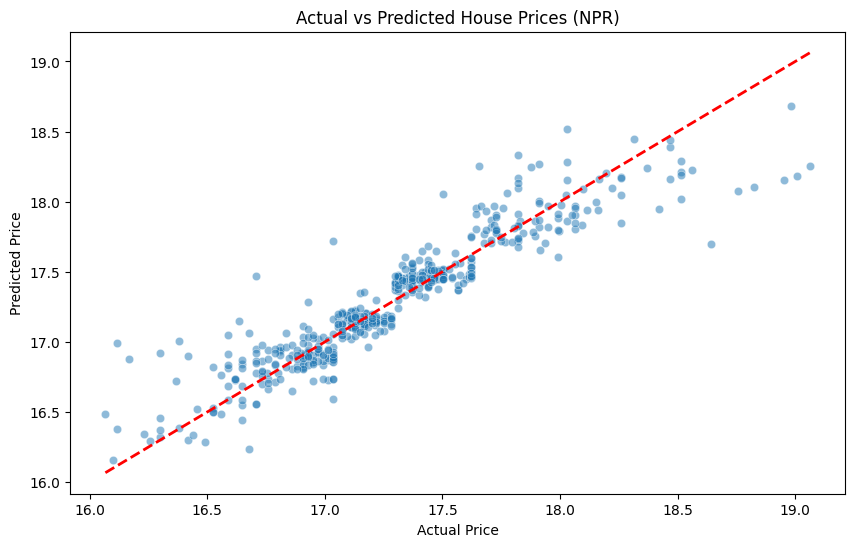

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Actual vs Predicted House Prices (NPR)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

In [35]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [36]:
# ─────────────────────────────────────────
# PARAMETER GRIDS FOR TOP 5 MODELS
# ─────────────────────────────────────────

param_grids = {
    'CatBoost': {
        'model': CatBoostRegressor(random_state=42, verbose=0),
        'params': {
            'iterations':       [100, 200, 300, 500],
            'learning_rate':    [0.01, 0.05, 0.1, 0.2],
            'depth':            [4, 6, 8, 10],
            'l2_leaf_reg':      [1, 3, 5, 7],
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {
            'n_estimators':     [100, 200, 300],
            'learning_rate':    [0.01, 0.05, 0.1, 0.2],
            'max_depth':        [3, 5, 7],
            'min_samples_split':[2, 5, 10],
            'subsample':        [0.7, 0.8, 1.0]
        }
    },
    'LightGBM': {
        'model': lgb.LGBMRegressor(random_state=42, verbose=-1),
        'params': {
            'n_estimators':     [100, 200, 300, 500],
            'learning_rate':    [0.01, 0.05, 0.1, 0.2],
            'max_depth':        [3, 5, 7, -1],
            'num_leaves':       [31, 50, 70, 100],
            'min_child_samples':[10, 20, 30]
        }
    },
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'n_estimators':     [100, 200, 300, 500],
            'max_depth':        [None, 10, 20, 30],
            'min_samples_split':[2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features':     ['sqrt', 'log2', 0.5]
        }
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=42, verbosity=0),
        'params': {
            'n_estimators':     [100, 200, 300, 500],
            'learning_rate':    [0.01, 0.05, 0.1, 0.2],
            'max_depth':        [3, 5, 7, 9],
            'subsample':        [0.7, 0.8, 1.0],
            'colsample_bytree': [0.7, 0.8, 1.0]
        }
    }
}

In [41]:
# ─────────────────────────────────────────
# TRAIN, TUNE AND STORE ALL 5 MODELS
# ─────────────────────────────────────────
tuned_models = {}  # stores best model for each
tuned_results = [] # stores metrics for comparison

for name, config in param_grids.items():
    print(f"🔍 Tuning {name}...")
    
    search = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        n_iter=30,
        cv=5,
        scoring='r2',
        random_state=42,
        n_jobs=-1
    )
    
    search.fit(X_train, y_train)
    
    # Store best model immediately before loop overwrites search
    tuned_models[name] = search.best_estimator_
            
    # Evaluate on test set
    y_pred = tuned_models[name].predict(X_test)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    mae    = mean_absolute_error(y_test, y_pred)
    r2     = r2_score(y_test, y_pred)
    
    tuned_results.append({
        'Model':       name,
        'RMSE (log)':  round(rmse, 4),
        'MAE (log)':   round(mae, 4),
        'R² Score':    round(r2, 4),
        'Error %':     f"{(np.exp(mae) - 1) * 100:.1f}%",
        'Best Params': search.best_params_
    })
    
    print(f"✅ {name} done — R²: {r2:.4f}")

print('HyperParameter Tuning Done ✅ ')

🔍 Tuning CatBoost...
✅ CatBoost done — R²: 0.9083
🔍 Tuning Gradient Boosting...
✅ Gradient Boosting done — R²: 0.9019
🔍 Tuning LightGBM...
✅ LightGBM done — R²: 0.9051
🔍 Tuning Random Forest...
✅ Random Forest done — R²: 0.9024
🔍 Tuning XGBoost...
✅ XGBoost done — R²: 0.9043
HyperParameter Tuning Done ✅ 


In [42]:
# ─────────────────────────────────────────
# COMPARE RESULTS
# ─────────────────────────────────────────
tuned_df = pd.DataFrame(tuned_results).sort_values('R² Score', ascending=False)
print("\n=== Tuned Model Comparison ===")
print(tuned_df[['Model', 'RMSE (log)', 'MAE (log)', 'R² Score', 'Error %']].to_string(index=False))



=== Tuned Model Comparison ===
            Model  RMSE (log)  MAE (log)  R² Score Error %
         CatBoost      0.1495     0.1042    0.9083   11.0%
         LightGBM      0.1521     0.1068    0.9051   11.3%
          XGBoost      0.1527     0.1051    0.9043   11.1%
    Random Forest      0.1542     0.1057    0.9024   11.2%
Gradient Boosting      0.1546     0.1063    0.9019   11.2%


In [43]:
print("\n=== Best Parameters ===")
for result in tuned_results:
    print(f"\n{result['Model']}:")
    for param, value in result['Best Params'].items():
        print(f"  {param}: {value}")


=== Best Parameters ===

CatBoost:
  learning_rate: 0.05
  l2_leaf_reg: 3
  iterations: 500
  depth: 6

Gradient Boosting:
  subsample: 0.7
  n_estimators: 100
  min_samples_split: 10
  max_depth: 5
  learning_rate: 0.05

LightGBM:
  num_leaves: 100
  n_estimators: 200
  min_child_samples: 10
  max_depth: 3
  learning_rate: 0.05

Random Forest:
  n_estimators: 500
  min_samples_split: 5
  min_samples_leaf: 2
  max_features: 0.5
  max_depth: 10

XGBoost:
  subsample: 0.7
  n_estimators: 500
  max_depth: 5
  learning_rate: 0.01
  colsample_bytree: 1.0


In [44]:
# ─────────────────────────────────────────
# SAVE CATBOOST (BEST MODEL)
# ─────────────────────────────────────────
import joblib
joblib.dump(tuned_models['CatBoost'], 'catboost_housing_model.pkl')
print("\n✅ CatBoost model saved as catboost_housing_model.pkl")



✅ CatBoost model saved as catboost_housing_model.pkl


In [45]:
# Verify it loads correctly
loaded_model = joblib.load('catboost_housing_model.pkl')
test_pred    = loaded_model.predict(X_test[:3])
print(f"✅ Load verification — sample predictions: {np.expm1(test_pred).astype(int)}")

✅ Load verification — sample predictions: [23085841 28890599 29335741]


In [48]:
# ─────────────────────────────────────────
# FEATURE IMPORTANCE
# ─────────────────────────────────────────
feature_names = X_train.columns.tolist()
importance    = tuned_models['CatBoost'].get_feature_importance()

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("=== Feature Importance (CatBoost) ===")
print(importance_df.to_string(index=False))

=== Feature Importance (CatBoost) ===
              Feature  Importance
        price_segment   61.467488
 neighborhood_encoded    7.626438
       land_area_aana    5.431673
             log_land    5.173767
        build_up_area    3.716302
         log_build_up    3.106304
               floors    2.409687
      road_width_feet    1.699551
            bathrooms    1.615835
        amenity_count    1.302597
             bedrooms    1.200664
            house_age    1.129134
               facing    1.027435
         luxury_score    0.776010
             district    0.611278
        parking_bikes    0.401525
          has_parquet    0.312519
         has_drainage    0.190175
    is_area_estimated    0.179644
  has_modular_kitchen    0.152587
         parking_cars    0.149155
is_incomplete_listing    0.124705
          has_parking    0.112631
           has_garden    0.079747
         is_wide_road    0.003150
             category    0.000000
            has_solar    0.000000
is_under_c

C:\Users\DELL\AppData\Local\Temp\ipykernel_6368\3814507560.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


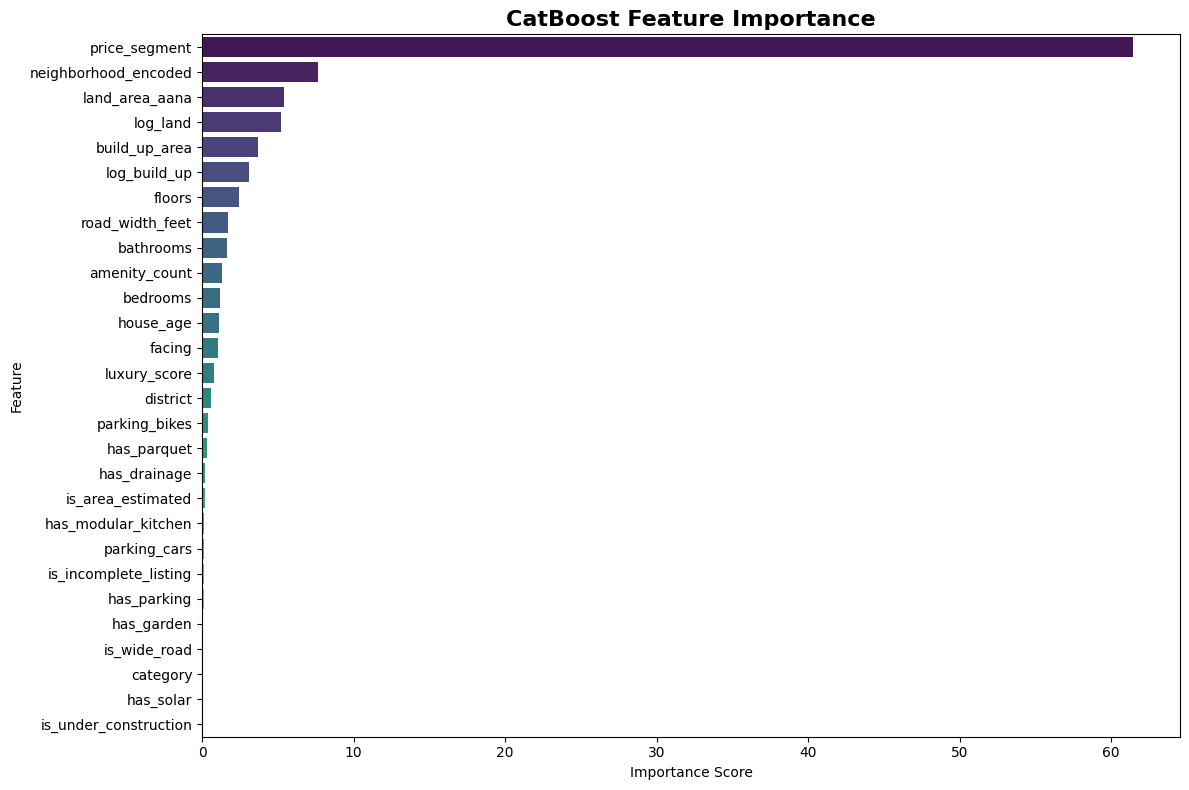

In [49]:
# Plot
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('CatBoost Feature Importance', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## EXTREME DATA LEAKAGE...AS PRICE SEGMENT IS DIRECTLY RELATED OR DERIEVED FROM TOTAL PTICE COLUMN.SO NOW WE HAVE TO REMOVE THE PRICE SEGMENT COLUMN AND RETRAIN AGAIN.. ##

In [52]:
# ─────────────────────────────────────────
# STEP 1 — RELOAD AND FIX DATA LEAKAGE
# ─────────────────────────────────────────
# Drop price_segment (leakage) and zero importance columns
drop_cols = ['price_segment', 'has_solar', 'is_under_construction', 'category']

X = df.drop(columns=['total_price'] + drop_cols, errors='ignore')
y = np.log1p(df['total_price'])

print(f"Features after fix: {X.shape[1]}")
print(f"Columns: {list(X.columns)}")

Features after fix: 24
Columns: ['district', 'land_area_aana', 'build_up_area', 'floors', 'facing', 'road_width_feet', 'bedrooms', 'bathrooms', 'parking_cars', 'parking_bikes', 'house_age', 'amenity_count', 'has_modular_kitchen', 'has_parquet', 'has_drainage', 'has_parking', 'has_garden', 'is_wide_road', 'is_area_estimated', 'luxury_score', 'is_incomplete_listing', 'log_land', 'log_build_up', 'neighborhood_encoded']


In [61]:
pd.set_option('display.max_columns',None)
X_train.sample(2)

,district,land_area_aana,build_up_area,floors,facing,road_width_feet,bedrooms,bathrooms,parking_cars,parking_bikes,house_age,amenity_count,has_modular_kitchen,has_parquet,has_drainage,has_parking,has_garden,is_wide_road,is_area_estimated,luxury_score,is_incomplete_listing,log_land,log_build_up,neighborhood_encoded
2396,2,3.1,2427.0,2.0,5,13.0,5.0,3.0,1.0,3.0,3.0,3,1,0,0,0,0,0,0,1,0,1.410987,7.794823,17.136122
1139,3,6.0,2874.9,2.0,0,13.0,4.0,3.0,0.0,0.0,11.0,4,0,0,0,1,0,0,1,1,1,1.945910,7.964121,16.453930


In [53]:
# ─────────────────────────────────────────
# STEP 2 — TRAIN TEST SPLIT
# ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")


Training samples: 2004
Testing samples:  502


In [54]:
# ─────────────────────────────────────────
# STEP 3 — RETRAIN ALL 5 MODELS
# ─────────────────────────────────────────
param_grids = {
    'CatBoost': {
        'model': CatBoostRegressor(random_state=42, verbose=0),
        'params': {
            'iterations':    [100, 200, 300, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'depth':         [4, 6, 8, 10],
            'l2_leaf_reg':   [1, 3, 5, 7],
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {
            'n_estimators':      [100, 200, 300],
            'learning_rate':     [0.01, 0.05, 0.1, 0.2],
            'max_depth':         [3, 5, 7],
            'min_samples_split': [2, 5, 10],
            'subsample':         [0.7, 0.8, 1.0]
        }
    },
    'LightGBM': {
        'model': lgb.LGBMRegressor(random_state=42, verbose=-1),
        'params': {
            'n_estimators':      [100, 200, 300, 500],
            'learning_rate':     [0.01, 0.05, 0.1, 0.2],
            'max_depth':         [3, 5, 7, -1],
            'num_leaves':        [31, 50, 70, 100],
            'min_child_samples': [10, 20, 30]
        }
    },
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'n_estimators':      [100, 200, 300, 500],
            'max_depth':         [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf':  [1, 2, 4],
            'max_features':      ['sqrt', 'log2', 0.5]
        }
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=42, verbosity=0),
        'params': {
            'n_estimators':     [100, 200, 300, 500],
            'learning_rate':    [0.01, 0.05, 0.1, 0.2],
            'max_depth':        [3, 5, 7, 9],
            'subsample':        [0.7, 0.8, 1.0],
            'colsample_bytree': [0.7, 0.8, 1.0]
        }
    }
}

tuned_models  = {}
tuned_results = []

for name, config in param_grids.items():
    print(f"🔍 Tuning {name}...")
    
    search = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        n_iter=30,
        cv=5,
        scoring='r2',
        random_state=42,
        n_jobs=-1
    )
    
    search.fit(X_train, y_train)
    tuned_models[name] = search.best_estimator_
    
    y_pred = tuned_models[name].predict(X_test)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    mae    = mean_absolute_error(y_test, y_pred)
    r2     = r2_score(y_test, y_pred)
    
    tuned_results.append({
        'Model':       name,
        'RMSE (log)':  round(rmse, 4),
        'MAE (log)':   round(mae, 4),
        'R² Score':    round(r2, 4),
        'Error %':     f"{(np.exp(mae) - 1) * 100:.1f}%",
        'Best Params': search.best_params_
    })
    
    print(f"✅ {name} done — R²: {r2:.4f}")
print('HyperParameter Tuning Done. ✅ ')

🔍 Tuning CatBoost...
✅ CatBoost done — R²: 0.7678
🔍 Tuning Gradient Boosting...
✅ Gradient Boosting done — R²: 0.7731
🔍 Tuning LightGBM...
✅ LightGBM done — R²: 0.7738
🔍 Tuning Random Forest...
✅ Random Forest done — R²: 0.7616
🔍 Tuning XGBoost...
✅ XGBoost done — R²: 0.7772
HyperParameter Tuning Done. ✅ 


In [55]:
# ─────────────────────────────────────────
# STEP 4 — COMPARE RESULTS
# ─────────────────────────────────────────
tuned_df = pd.DataFrame(tuned_results).sort_values('R² Score', ascending=False)
print("\n=== Tuned Model Comparison (Leakage Fixed) ===")
print(tuned_df[['Model', 'RMSE (log)', 'MAE (log)', 'R² Score', 'Error %']].to_string(index=False))

print("\n=== Best Parameters ===")
for result in tuned_results:
    print(f"\n{result['Model']}:")
    for param, value in result['Best Params'].items():
        print(f"  {param}: {value}")


=== Tuned Model Comparison (Leakage Fixed) ===
            Model  RMSE (log)  MAE (log)  R² Score Error %
          XGBoost      0.2330     0.1721    0.7772   18.8%
         LightGBM      0.2348     0.1723    0.7738   18.8%
Gradient Boosting      0.2351     0.1735    0.7731   18.9%
         CatBoost      0.2379     0.1730    0.7678   18.9%
    Random Forest      0.2410     0.1731    0.7616   18.9%

=== Best Parameters ===

CatBoost:
  learning_rate: 0.2
  l2_leaf_reg: 7
  iterations: 100
  depth: 4

Gradient Boosting:
  subsample: 0.7
  n_estimators: 200
  min_samples_split: 5
  max_depth: 3
  learning_rate: 0.05

LightGBM:
  num_leaves: 100
  n_estimators: 200
  min_child_samples: 10
  max_depth: 3
  learning_rate: 0.05

Random Forest:
  n_estimators: 300
  min_samples_split: 5
  min_samples_leaf: 2
  max_features: 0.5
  max_depth: 30

XGBoost:
  subsample: 0.8
  n_estimators: 300
  max_depth: 3
  learning_rate: 0.05
  colsample_bytree: 0.7


In [57]:
feature_names = X_train.columns.tolist()

# XGBoost uses feature_importances_ not get_feature_importance()
importance = tuned_models['XGBoost'].feature_importances_

importance_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("\n=== Feature Importance (XGBoost - Leakage Fixed) ===")
print(importance_df.to_string(index=False))




=== Feature Importance (XGBoost - Leakage Fixed) ===
              Feature  Importance
             log_land    0.301652
       land_area_aana    0.199218
         log_build_up    0.119981
 neighborhood_encoded    0.096958
        build_up_area    0.042062
            bathrooms    0.037770
  has_modular_kitchen    0.019792
             district    0.018919
               floors    0.017558
          has_parquet    0.017317
      road_width_feet    0.016313
is_incomplete_listing    0.012263
        amenity_count    0.010879
         luxury_score    0.010366
             bedrooms    0.009860
    is_area_estimated    0.009211
         is_wide_road    0.008499
               facing    0.008164
        parking_bikes    0.008135
         parking_cars    0.008061
            house_age    0.007436
         has_drainage    0.006803
          has_parking    0.006722
           has_garden    0.006060


C:\Users\DELL\AppData\Local\Temp\ipykernel_6368\1839866667.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


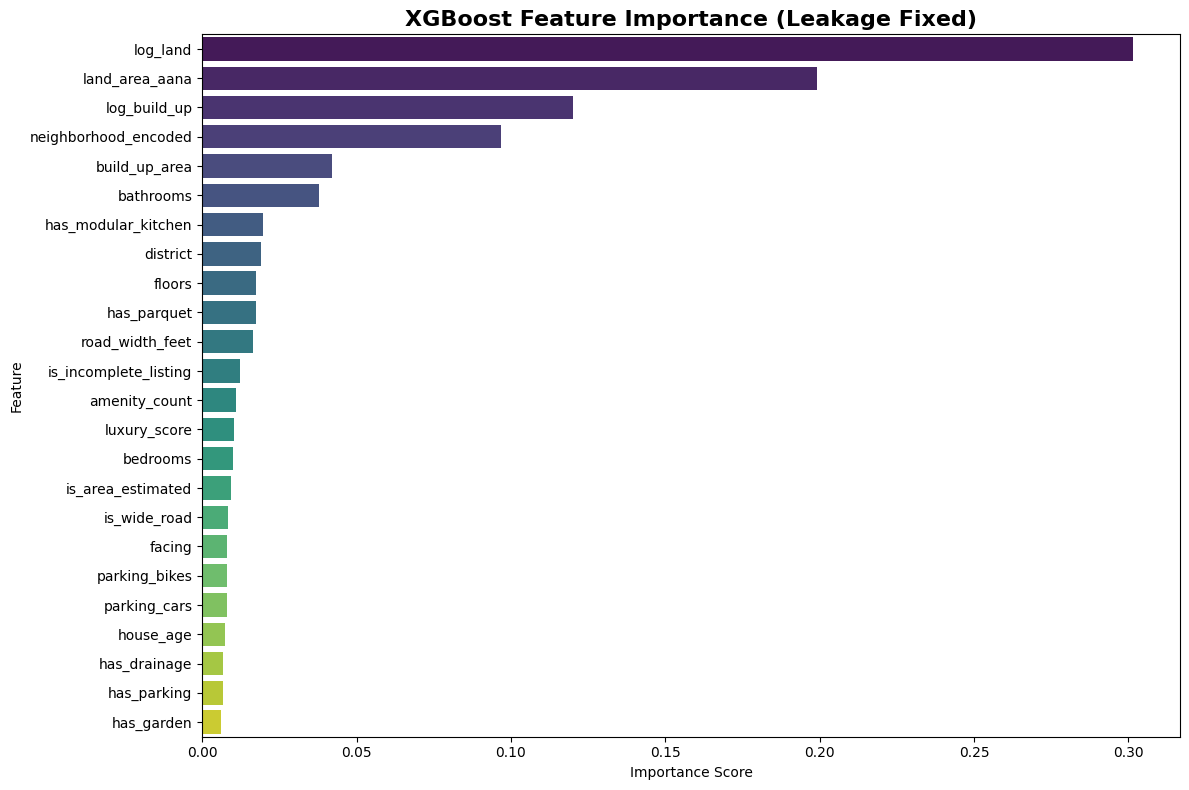

In [58]:
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('XGBoost Feature Importance (Leakage Fixed)', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [62]:

df_improved = df.copy()


In [64]:
# Interaction features
df_improved['land_x_neighborhood'] = df_improved['land_area_aana'] * df_improved['neighborhood_encoded']
df_improved['area_per_floor']      = df_improved['build_up_area'] / df_improved['floors'].replace(0, 1)
df_improved['room_ratio']          = df_improved['bedrooms'] / df_improved['floors'].replace(0, 1)
df_improved['bath_bed_ratio']      = df_improved['bathrooms'] / df_improved['bedrooms'].replace(0, 1)

print("✅ New features added:")
print(['land_x_neighborhood', 'area_per_floor', 'room_ratio', 'bath_bed_ratio'])

✅ New features added:
['land_x_neighborhood', 'area_per_floor', 'room_ratio', 'bath_bed_ratio']


## Land × Neighborhood: This combines size and location. It tells the model that 1 Aana in a posh area like Sanepa is worth much more than 1 Aana in a remote area.

## Area per Floor: This shows the house shape. It helps the model tell the difference between a wide, luxurious bungalow and a tall, narrow building.

## Room Ratio: This shows how crowded the house is. It measures if the floors are packed with many small rooms or have fewer, large, open spaces.

## Bath-to-Bed Ratio: This is a luxury signal. Modern, expensive houses in Kathmandu usually have a bathroom for every bedroom (attached). A higher number here usually means a higher price.

In [65]:
# ─────────────────────────────────────────
# STEP 2 — REDEFINE X AND Y
# ─────────────────────────────────────────
drop_cols = ['price_segment', 'has_solar', 'is_under_construction', 
             'category', 'total_price']

X = df_improved.drop(columns=drop_cols, errors='ignore')
y = np.log1p(df_improved['total_price'])

print(f"\nFeatures before: 24")
print(f"Features after:  {X.shape[1]}")


Features before: 24
Features after:  28


In [66]:
# ─────────────────────────────────────────
# STEP 3 — TRAIN TEST SPLIT
# ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [67]:
# ─────────────────────────────────────────
# STEP 4 — RETRAIN ALL 5 MODELS
# ─────────────────────────────────────────
tuned_models_v2  = {}
tuned_results_v2 = []

for name, config in param_grids.items():
    print(f"🔍 Tuning {name}...")
    
    search = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        n_iter=30,
        cv=5,
        scoring='r2',
        random_state=42,
        n_jobs=-1
    )
    
    search.fit(X_train, y_train)
    tuned_models_v2[name] = search.best_estimator_
    
    y_pred = tuned_models_v2[name].predict(X_test)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    mae    = mean_absolute_error(y_test, y_pred)
    r2     = r2_score(y_test, y_pred)
    
    tuned_results_v2.append({
        'Model':      name,
        'RMSE (log)': round(rmse, 4),
        'MAE (log)':  round(mae, 4),
        'R² Score':   round(r2, 4),
        'Error %':    f"{(np.exp(mae) - 1) * 100:.1f}%"
    })
    
    print(f"✅ {name} done — R²: {r2:.4f}")
Print('HyperParameter Tuning Done. ✅')

🔍 Tuning CatBoost...
✅ CatBoost done — R²: 0.7686
🔍 Tuning Gradient Boosting...
✅ Gradient Boosting done — R²: 0.7688
🔍 Tuning LightGBM...
✅ LightGBM done — R²: 0.7686
🔍 Tuning Random Forest...
✅ Random Forest done — R²: 0.7594
🔍 Tuning XGBoost...
✅ XGBoost done — R²: 0.7684


NameError: name 'Print' is not defined

In [68]:
# ─────────────────────────────────────────
# STEP 5 — COMPARE OLD VS NEW
# ─────────────────────────────────────────
tuned_df_v2 = pd.DataFrame(tuned_results_v2).sort_values('R² Score', ascending=False)

print("\n=== Before Feature Engineering ===")
print(tuned_df[['Model', 'R² Score', 'Error %']].to_string(index=False))

print("\n=== After Feature Engineering ===")
print(tuned_df_v2[['Model', 'R² Score', 'Error %']].to_string(index=False))


=== Before Feature Engineering ===
            Model  R² Score Error %
          XGBoost    0.7772   18.8%
         LightGBM    0.7738   18.8%
Gradient Boosting    0.7731   18.9%
         CatBoost    0.7678   18.9%
    Random Forest    0.7616   18.9%

=== After Feature Engineering ===
            Model  R² Score Error %
Gradient Boosting    0.7688   18.9%
         CatBoost    0.7686   18.9%
         LightGBM    0.7686   19.0%
          XGBoost    0.7684   18.8%
    Random Forest    0.7594   18.9%


In [69]:
# ─────────────────────────────────────────
# STEP 6 — FEATURE IMPORTANCE OF BEST MODEL
# ─────────────────────────────────────────
best_model_name = tuned_df_v2.iloc[0]['Model']
print(f"\nBest model: {best_model_name}")

importance    = tuned_models_v2[best_model_name].feature_importances_
importance_df = pd.DataFrame({
    'Feature':    X_train.columns.tolist(),
    'Importance': importance
}).sort_values('Importance', ascending=False)

print(importance_df.to_string(index=False))


Best model: Gradient Boosting
              Feature  Importance
  land_x_neighborhood    0.598467
 neighborhood_encoded    0.194758
        build_up_area    0.062378
         log_build_up    0.051110
            bathrooms    0.022325
               floors    0.021278
      road_width_feet    0.014086
       area_per_floor    0.007306
        amenity_count    0.005371
             district    0.004178
       bath_bed_ratio    0.003731
           room_ratio    0.002517
             bedrooms    0.002350
             log_land    0.001989
          has_parquet    0.001723
         luxury_score    0.001366
            house_age    0.001150
is_incomplete_listing    0.000830
    is_area_estimated    0.000650
         parking_cars    0.000615
       land_area_aana    0.000537
               facing    0.000523
          has_parking    0.000404
  has_modular_kitchen    0.000187
         is_wide_road    0.000173
        parking_bikes    0.000000
           has_garden    0.000000
         has_drai

C:\Users\DELL\AppData\Local\Temp\ipykernel_6368\3704793262.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


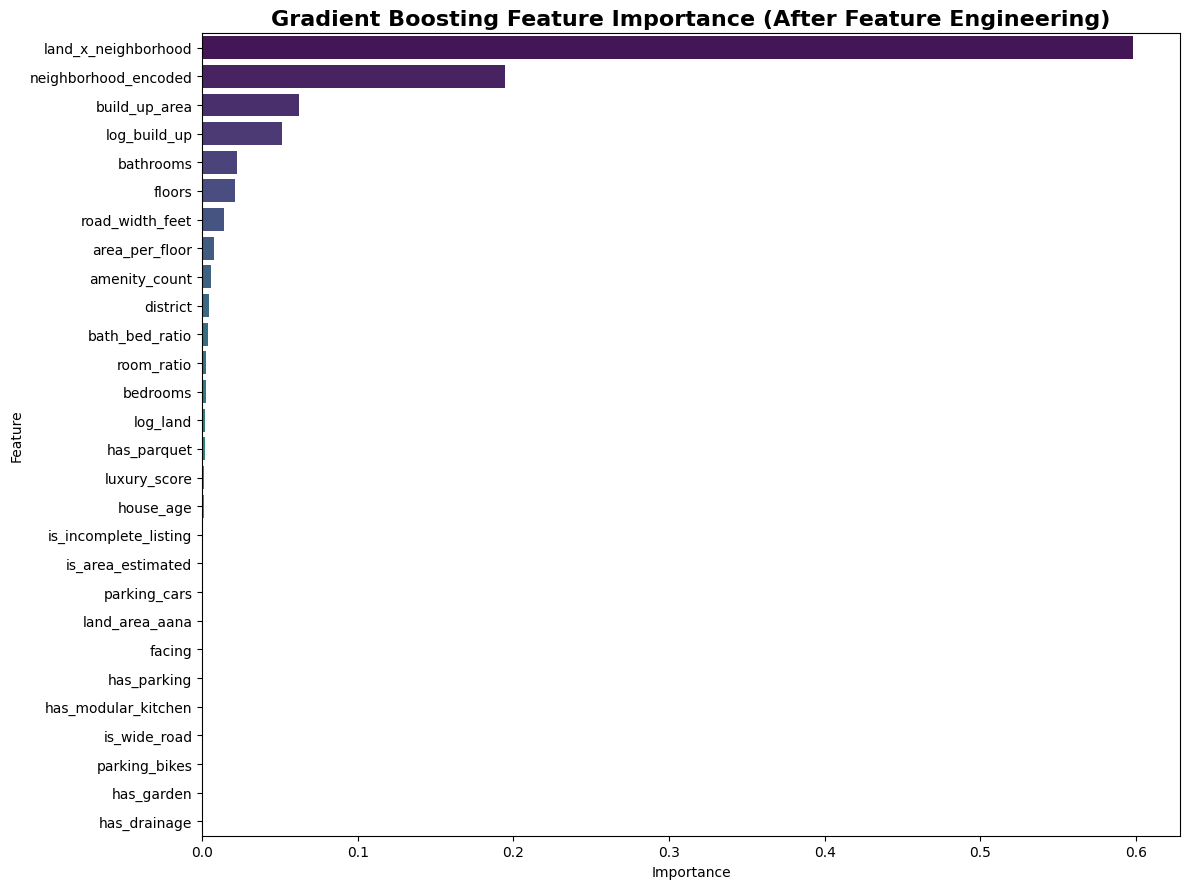

In [70]:
plt.figure(figsize=(12, 9))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title(f'{best_model_name} Feature Importance (After Feature Engineering)',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [71]:
print("\n=== Before Feature Engineering ===")
print(tuned_df[['Model', 'R² Score', 'Error %']].to_string(index=False))

print("\n=== After Feature Engineering ===")
print(tuned_df_v2[['Model', 'R² Score', 'Error %']].to_string(index=False))


=== Before Feature Engineering ===
            Model  R² Score Error %
          XGBoost    0.7772   18.8%
         LightGBM    0.7738   18.8%
Gradient Boosting    0.7731   18.9%
         CatBoost    0.7678   18.9%
    Random Forest    0.7616   18.9%

=== After Feature Engineering ===
            Model  R² Score Error %
Gradient Boosting    0.7688   18.9%
         CatBoost    0.7686   18.9%
         LightGBM    0.7686   19.0%
          XGBoost    0.7684   18.8%
    Random Forest    0.7594   18.9%


## After new feature extraction didnt helped at all..so better using xgboost as previous ##

In [74]:
drop_cols = ['price_segment', 'has_solar', 'is_under_construction', 
             'category', 'total_price']

X_original = df.drop(columns=drop_cols, errors='ignore')
y_original = np.log1p(df['total_price'])

# Recreate the exact same split with same random_state
X_train, X_test, y_train, y_test = train_test_split(
    X_original, y_original, test_size=0.2, random_state=42
)

In [75]:
import joblib
loaded = joblib.load('xgboost_housing_final.pkl')
preds  = loaded.predict(X_test[:3])
print(f"✅ Sample predictions: {np.expm1(preds).astype(int)}")

✅ Sample predictions: [31247028 30302416 31923728]
